# Multivariate Multistep TimeSeries 실습

- 가구의 Energy 사용량 예측

- Household Power Consumption Dataset 은 한 가구의 4 년간 전력소비를 나타내는 multivariate time series dataset 임

- data는  분 단위 관측값으로 구성

- variables :  

    - global active power: 가구에서 소비한 총 유효전력 (total active power, kilowatts).
    - global reactive power: 가구에서 소비한 총 무효전력 (total reactive power, kilowatts).
    - voltage: 평균 voltage (volts).
    - global intensity: 평균 전류 밀도 (amps).
    - sub metering 1: 주방에서 사용된 active energy (watt-hours of active energy).
    - sub metering 2: 세탁에 사용된 active energy (watt-hours of active energy).
    - sub metering 3: 공조기 제어 시스템에 사용된 active energy (watt-hours of active energy).

- 기타 다른 곳에서 시용된 active energy $\left(\frac{global\_act\_pwr  \times  1000}{60} \right) - \left(sub met 1 + sub met 2 + sub met 3\right) $

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import tensorflow as tf

In [2]:
url = "https://raw.githubusercontent.com/ironmanciti/Time_Series_Lecture/main/datasets/household_power_consumption_days.csv"
dataset = pd.read_csv(url, index_col=['datetime'], parse_dates=True)

print(dataset.shape)
print(dataset.info())
dataset.head()

(1442, 8)
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1442 entries, 2006-12-16 to 2010-11-26
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Global_active_power    1442 non-null   float64
 1   Global_reactive_power  1442 non-null   float64
 2   Voltage                1442 non-null   float64
 3   Global_intensity       1442 non-null   float64
 4   Sub_metering_1         1442 non-null   float64
 5   Sub_metering_2         1442 non-null   float64
 6   Sub_metering_3         1442 non-null   float64
 7   Sub_metering_4         1442 non-null   float64
dtypes: float64(8)
memory usage: 101.4 KB
None


,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,Sub_metering_4
datetime,,,,,,,,
2006-12-16,1209.176,34.922,93552.53,5180.8,0.0,546.0,4926.0,14680.933319
2006-12-17,3390.460,226.006,345725.32,14398.6,2033.0,4187.0,13341.0,36946.666732
2006-12-18,2203.826,161.792,347373.64,9247.2,1063.0,2621.0,14018.0,19028.433281
2006-12-19,1666.194,150.942,348479.01,7094.0,839.0,7602.0,6197.0,13131.900043
2006-12-20,2225.748,160.998,348923.61,9313.0,0.0,2648.0,14063.0,20384.800011


## Exploratory Data Analysis(탐색적 데이터 분석)

#### multivariate data 이므로 각각의 변수에 대해 line plot 을 그려 비교 (기간 : 2006 Dec 에서 2010 Nov 까지)

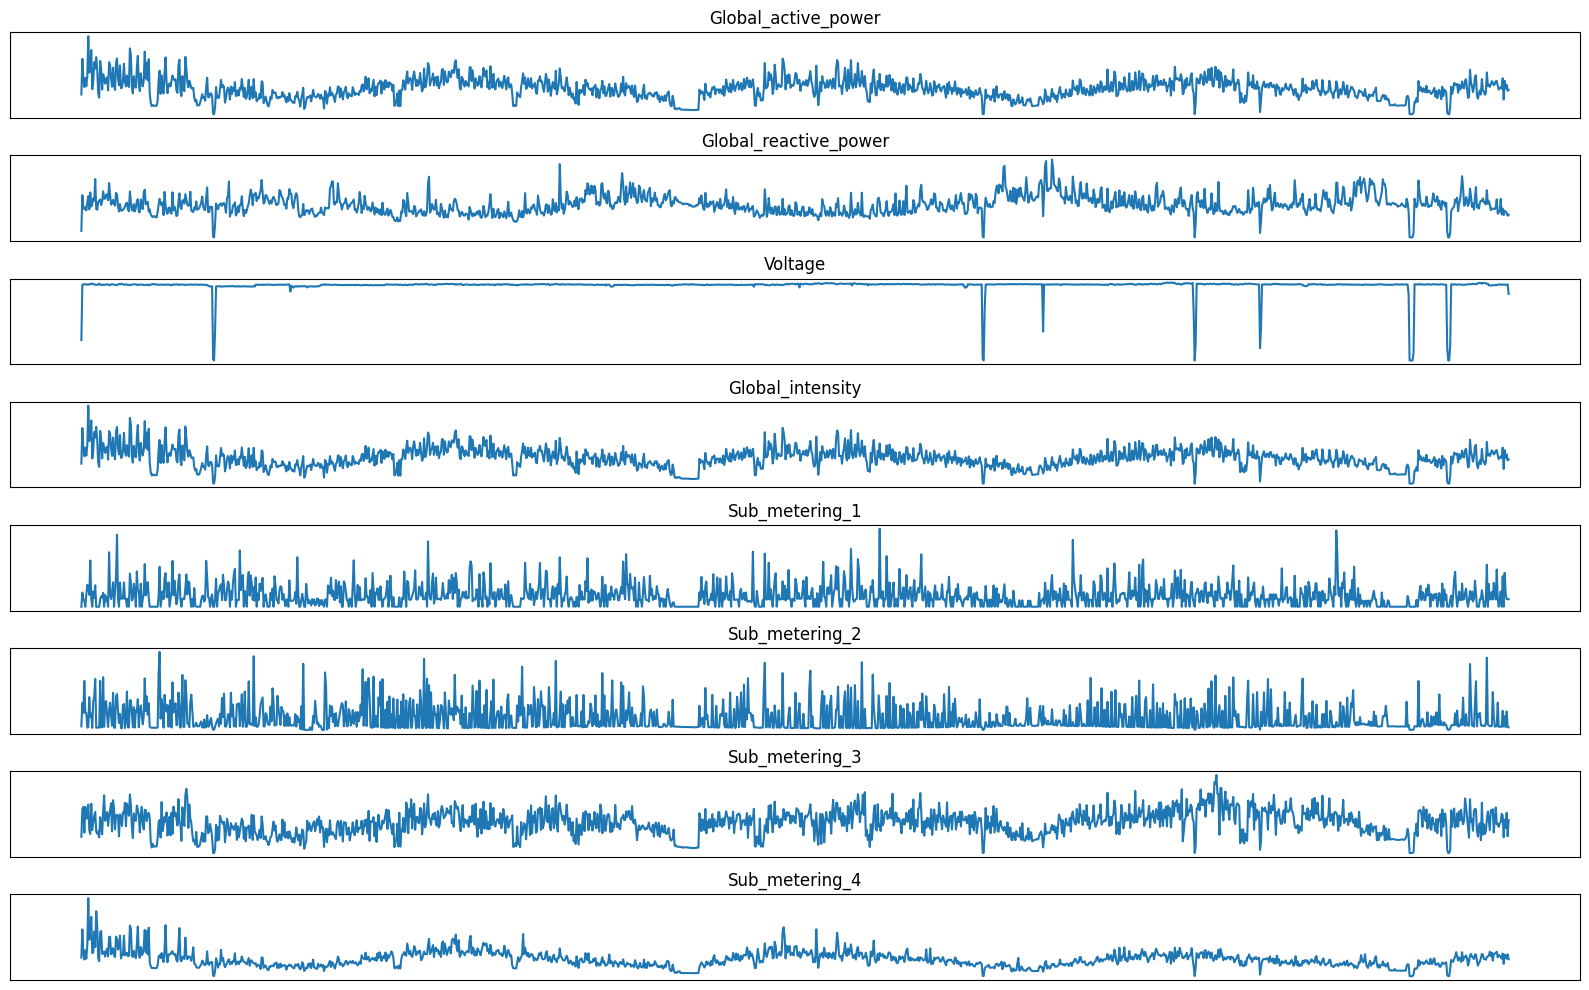

In [3]:
plt.figure(figsize=(16, 10))
for i in range(len(dataset.columns)):
    plt.subplot(len(dataset.columns), 1, i+1)
    name = dataset.columns[i]
    plt.plot(dataset[name])
    plt.title(name)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()

## 개별 변수에 대하여 분석

#### Global_active_power (총 소비전력)를 연도별로 plot

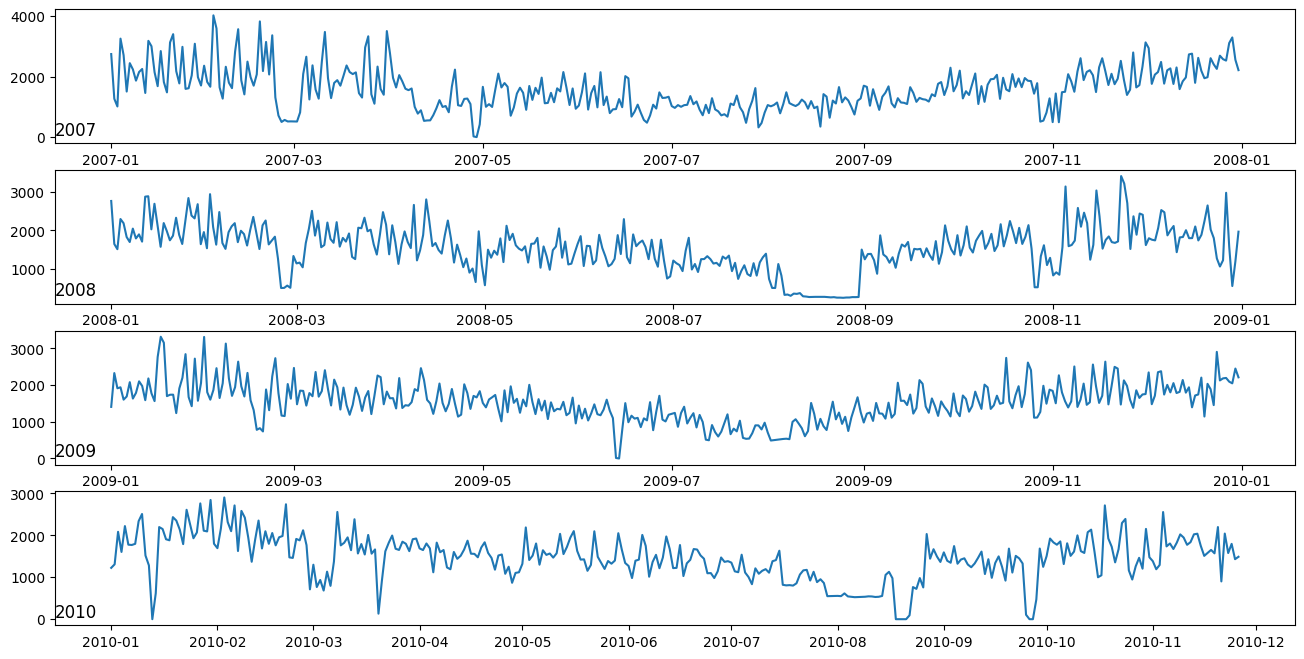

In [4]:
years = ['2007', '2008', '2009', '2010']  # 분석할 연도 목록 지정

plt.figure(figsize=(16, 8))

for i in range(len(years)):
    ax = plt.subplot(len(years), 1, i+1)    # 연도별로 세로 방향 서브플롯 생성
    ax.plot(dataset.loc[years[i], 'Global_active_power'])    # 해당 연도의 전력 사용량 시계열 그래프 출력
    ax.set_title(years[i], y=0, loc='left')    # 서브플롯 제목을 왼쪽에 표시

#### Global_active_power 를 특정연도(2007) 의 월별로 plot

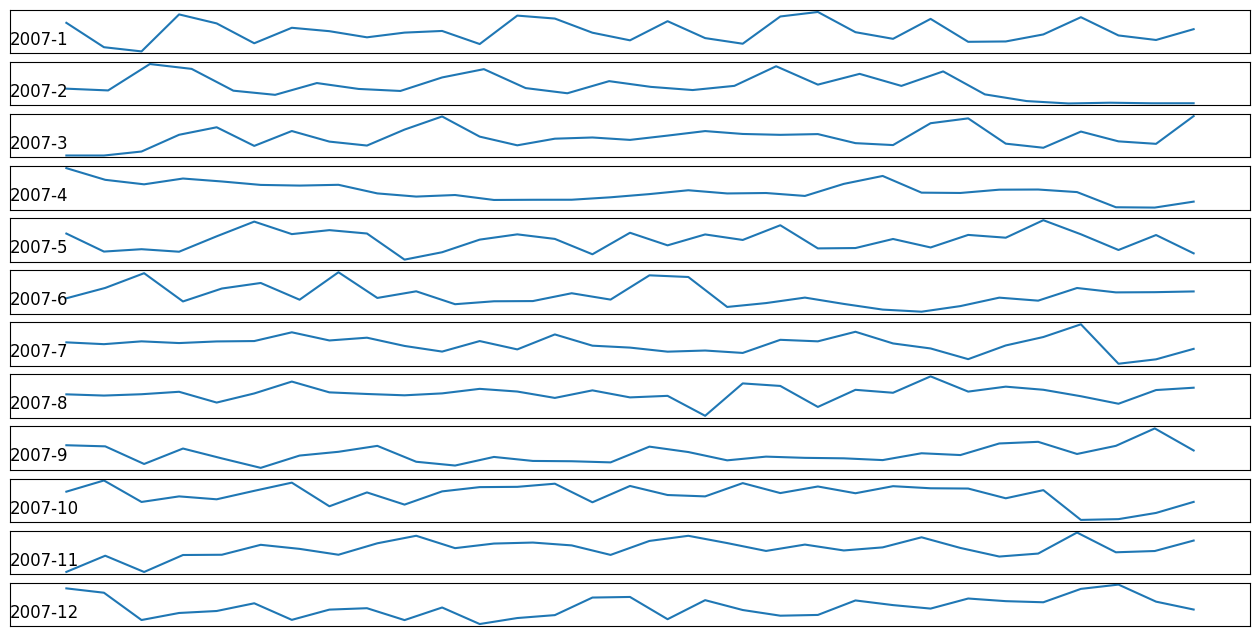

In [5]:
months = [i for i in range(1, 13)]  # 1월부터 12월까지의 월 리스트 생성
plt.figure(figsize=(16, 8))

for i in range(len(months)):
    ax = plt.subplot(len(months), 1, i+1)   # 12행 1열 형태의 서브플롯 생성
    YYMM = '2007-' + str(months[i])         # '2007-1', '2007-2' 형태의 문자열 생성
    result = dataset.loc[YYMM]              # 해당 월(YYMM)에 해당하는 데이터만 추출
    ax.plot(result['Global_active_power'])  # 해당 월의 전력 사용량 시계열 그래프 그리기
    ax.set_title(YYMM, y=0, loc='left')     # 각 서브플롯 제목을 왼쪽에 표시
    ax.set_xticks([])                       # x축 눈금 숨기기
    ax.set_yticks([])                       # y축 눈금 숨기기

#### Global_active_power 를 특정연도(2007) 의 특정월(January)의 일별로 plot

<Axes: xlabel='datetime'>

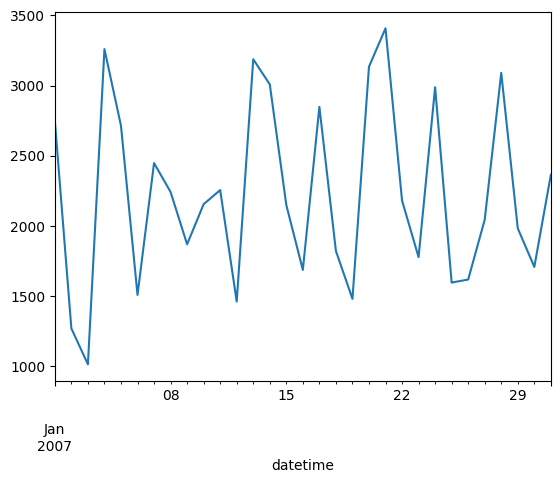

In [6]:
day1 = '2007-01-01'                     # 조회 시작 날짜 지정
day2 = '2007-01-31'                     # 조회 종료 날짜 지정
result = dataset.loc[day1:day2]         # 시작일~종료일 범위의 데이터 추출
result['Global_active_power'].plot()    # 해당 기간의 전력 사용량 시계열 그래프 출력

## 문제

- Multivariate multi-step forecasting (다변수 다단계 예측)

- next week 의 일별 전력 사용량(global active power) 예측  
    

- 이전 7일간의 전력 사용량으로 next week 사용량을 예측 하므로 window_size = 7

In [7]:
dataset.shape

(1442, 8)

In [8]:
dataset.index.year.value_counts()

,count
datetime,
2008,366
2009,365
2007,365
2010,330
2006,16


## Train – Test Split

2010년 이 330 record 이므로 2010년을 Test set 으로 사용하고 이전 data를 Train set 으로 분할

In [9]:
split_time = dataset.shape[0] - 330   # 전체 데이터 개수에서 마지막 330개를 테스트 데이터로 사용하기 위한 분할 기준 계산

time_train = dataset.index[:split_time]   # 분할 기준 이전까지의 인덱스를 학습용 시간축으로 저장
time_test = dataset.index[split_time:]    # 분할 기준 이후의 인덱스를 테스트용 시간축으로 저장

d_train = dataset.values[:split_time]     # 분할 기준 이전까지의 실제 데이터 값을 학습용 데이터로 저장
d_test  = dataset.values[split_time:]     # 분할 기준 이후의 실제 데이터 값을 테스트용 데이터로 저장

time_train.shape, time_test.shape, d_train.shape, d_test.shape  # 각 데이터의 크기(형태) 확인

((1112,), (330,), (1112, 8), (330, 8))

## Scaling the values
- 다변수 문제 이므로 feature value 들을 normalize

In [10]:
sc = StandardScaler()
d_train_scaled = sc.fit_transform(d_train)
d_test_scaled = sc.transform(d_test)

In [11]:
# 입력 시계열 데이터를 tf.data.Dataset 형태로 변환하는 함수 정의
def windowed_dataset(series, window_size, batch_size, shuffle_buffer=0):

    # 입력 시계열 데이터를 TensorFlow Dataset 객체로 변환
    dataset = tf.data.Dataset.from_tensor_slices(series)

    # 길이가 window_size+1 인 윈도우를 1칸씩 이동하며 생성
    # 길이가 부족한 마지막 구간은 제외
    dataset = dataset.window(window_size + 1, shift=1, drop_remainder=True)

    # 각 윈도우를 실제 텐서(배치) 형태로 변환
    dataset = dataset.flat_map(lambda w: w.batch(window_size + 1))

    # shuffle_buffer 값이 0보다 크면 데이터 순서를 섞음
    # 보통 학습용 데이터셋에서만 사용
    if shuffle_buffer > 0:
        dataset = dataset.shuffle(shuffle_buffer)

    # 입력(X)은 마지막 1개를 제외한 구간
    # 정답(y)은 다음 시점의 첫 번째 컬럼(Global_active_power)만 사용
    dataset = dataset.map(lambda w: (w[:-1], w[1:, 0:1]))

    # 지정한 크기만큼 배치로 묶고, 다음 배치를 미리 준비
    dataset = dataset.batch(batch_size).prefetch(1)

    # 최종 데이터셋 반환
    return dataset

In [12]:
# 입력 시퀀스 길이를 7로 설정 (일주일 단위 윈도우)
window_size = 7

# 입력 변수(특성) 개수를 8개로 설정
n_features = 8

# 학습 데이터 셔플용 버퍼 크기 설정
shuffle_buffer = 100

# 한 번에 묶어서 처리할 배치 크기 설정
batch_size = 64

# 학습용 데이터셋 생성
# 윈도우 분할 후 셔플을 적용하여 모델 학습에 사용
train_ds = windowed_dataset(d_train_scaled, window_size, batch_size, shuffle_buffer)

# 테스트용 데이터셋 생성
# 테스트 데이터는 시계열 순서를 유지해야 하므로 셔플 없이 생성
test_ds = windowed_dataset(d_test_scaled, window_size, batch_size)

# 생성된 이터셋 정보 출력
print(train_ds)
print(test_ds)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 8), dtype=tf.float64, name=None), TensorSpec(shape=(None, None, 1), dtype=tf.float64, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 8), dtype=tf.float64, name=None), TensorSpec(shape=(None, None, 1), dtype=tf.float64, name=None))>


In [13]:
model = tf.keras.models.Sequential([
    tf.keras.Input(shape=(window_size, n_features)),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.LSTM(64, return_sequences=True),
    tf.keras.layers.Dense(120, activation='relu'),
    tf.keras.layers.Dense(1),
])

model.compile(loss='mse', optimizer='adam')

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 64)          │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 7, 64)          │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 7, 120)         │         7,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7, 1)           │           121 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,633 (232.94 KB)

 Trainable params: 59,633 (232.94 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
%%time
history = model.fit(train_ds, epochs=50, validation_data=test_ds, verbose=2)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:160: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


18/18 - 5s - 288ms/step - loss: 0.8385 - val_loss: 0.5411
Epoch 2/50
18/18 - 0s - 13ms/step - loss: 0.6602 - val_loss: 0.5012
Epoch 3/50
18/18 - 0s - 14ms/step - loss: 0.6198 - val_loss: 0.4561
Epoch 4/50
18/18 - 0s - 15ms/step - loss: 0.5785 - val_loss: 0.4305
Epoch 5/50
18/18 - 0s - 13ms/step - loss: 0.5593 - val_loss: 0.4225
Epoch 6/50
18/18 - 0s - 14ms/step - loss: 0.5414 - val_loss: 0.4089
Epoch 7/50
18/18 - 0s - 14ms/step - loss: 0.5245 - val_loss: 0.4026
Epoch 8/50
18/18 - 0s - 13ms/step - loss: 0.5112 - val_loss: 0.3991
Epoch 9/50
18/18 - 0s - 14ms/step - loss: 0.5054 - val_loss: 0.3998
Epoch 10/50
18/18 - 0s - 13ms/step - loss: 0.4969 - val_loss: 0.3934
Epoch 11/50
18/18 - 1s - 71ms/step - loss: 0.4908 - val_loss: 0.3923
Epoch 12/50
18/18 - 0s - 16ms/step - loss: 0.4844 - val_loss: 0.3919
Epoch 13/50
18/18 - 0s - 13ms/step - loss: 0.4770 - val_loss: 0.3901
Epoch 14/50
18/18 - 1s - 43ms/step - loss: 0.4729 - val_loss: 0.3927
Epoch 15/50
18/18 - 0s - 13ms/step - loss: 0.4665 - v

`d_test_scaled`의 첫번째 column (`Global_active_power`)을 y_test 로 저장

In [15]:
y_test = np.array([day[0] for day in d_test_scaled])
y_test.shape

(330,)

In [16]:
prediction = model.predict(test_ds)[:, -1, 0]
prediction.shape

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


(323,)

원래 크기로 denormalize

In [17]:
# StandardScaler의 inverse_transform을 사용하기 위해
# 전체 feature 개수만큼 0으로 채운 dummy 배열을 만든 뒤
# 복원할 컬럼 위치에만 예측값 또는 실제값을 넣어 역정규화하는 함수 정의
def inverse_scale(values, scaler, col_idx=0):

    # (샘플 수, 전체 feature 수) 크기의 0 배열 생성
    dummy = np.zeros((len(values), scaler.n_features_in_))

    # 복원할 대상 컬럼(col_idx)에 values 값을 채움
    dummy[:, col_idx] = values

    # 전체 feature 형태로 inverse_transform 수행 후
    # 다시 대상 컬럼만 추출하여 반환
    return scaler.inverse_transform(dummy)[:, col_idx]

# 테스트 실제값(y_test)을 원래 스케일로 복원
y_true = inverse_scale(y_test, sc)

# 모델 예측값(prediction)을 원래 스케일로 복원
y_pred = inverse_scale(prediction, sc)

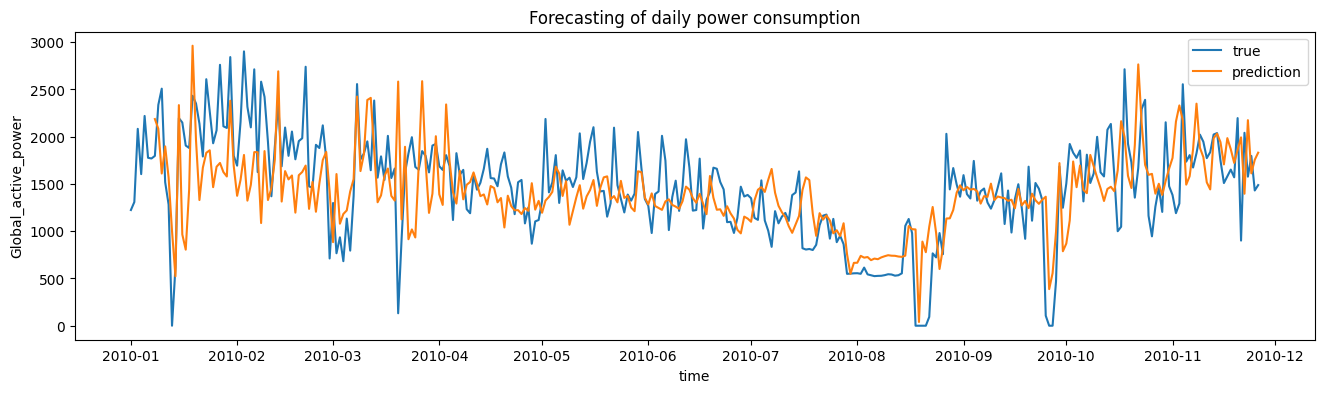

In [18]:
# 전체 예측 결과 시각화 (실제값 vs 예측값 비교)
plt.figure(figsize=(16, 4))
plt.plot(time_test, y_true, label='true')                # 실제값 (테스트 구간)
plt.plot(time_test[-len(y_pred):], y_pred, label='prediction')  # 예측값
plt.xlabel("time")                    # x축: 시간
plt.ylabel("Global_active_power")     # y축: 일별 전력 소비량
plt.title("Forecasting of daily power consumption")  # 일별 전력 소비 예측
plt.legend()

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 예측값 길이에 맞춰 실제값 정렬 (뒤에서부터 동일 길이 추출)
y_true_aligned = y_true[-len(y_pred):]

# 평균 절대 오차(MAE)와 평균 제곱근 오차(RMSE) 계산
print(f"MAE:  {mean_absolute_error(y_true_aligned, y_pred):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_true_aligned, y_pred)):.2f}")

MAE:  346.52
RMSE: 459.81
